In [2]:
# Adapted from Anthropic Claude API Course
# Modified and extended for learning and experimentation

# LLM Temperature Tuning

### Environmental Set up

In [1]:
# Install dependencies
%pip install anthropic python-dotenv

You should consider upgrading via the '/Users/upasanaghosh/ml-dev-workspace/building_with_claude_api/.buildingWithClaudeAPI/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load env variables
from dotenv import load_dotenv
import os

print("API key loaded:", load_dotenv())

API key loaded: True


In [3]:
# Create API client
from anthropic import Anthropic

client = Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
model = "claude-sonnet-4-0"

## Temperature Tuning

Temperature is a powerful parameter that controls how predictable or creative Claude's responses will be. When you send Claude a prompt like "What do you think?", it goes through three key steps:

- Tokenization - Breaking your input into smaller chunks
- Prediction - Calculating probabilities for possible next words
- Sampling - Choosing a token based on those probabilities

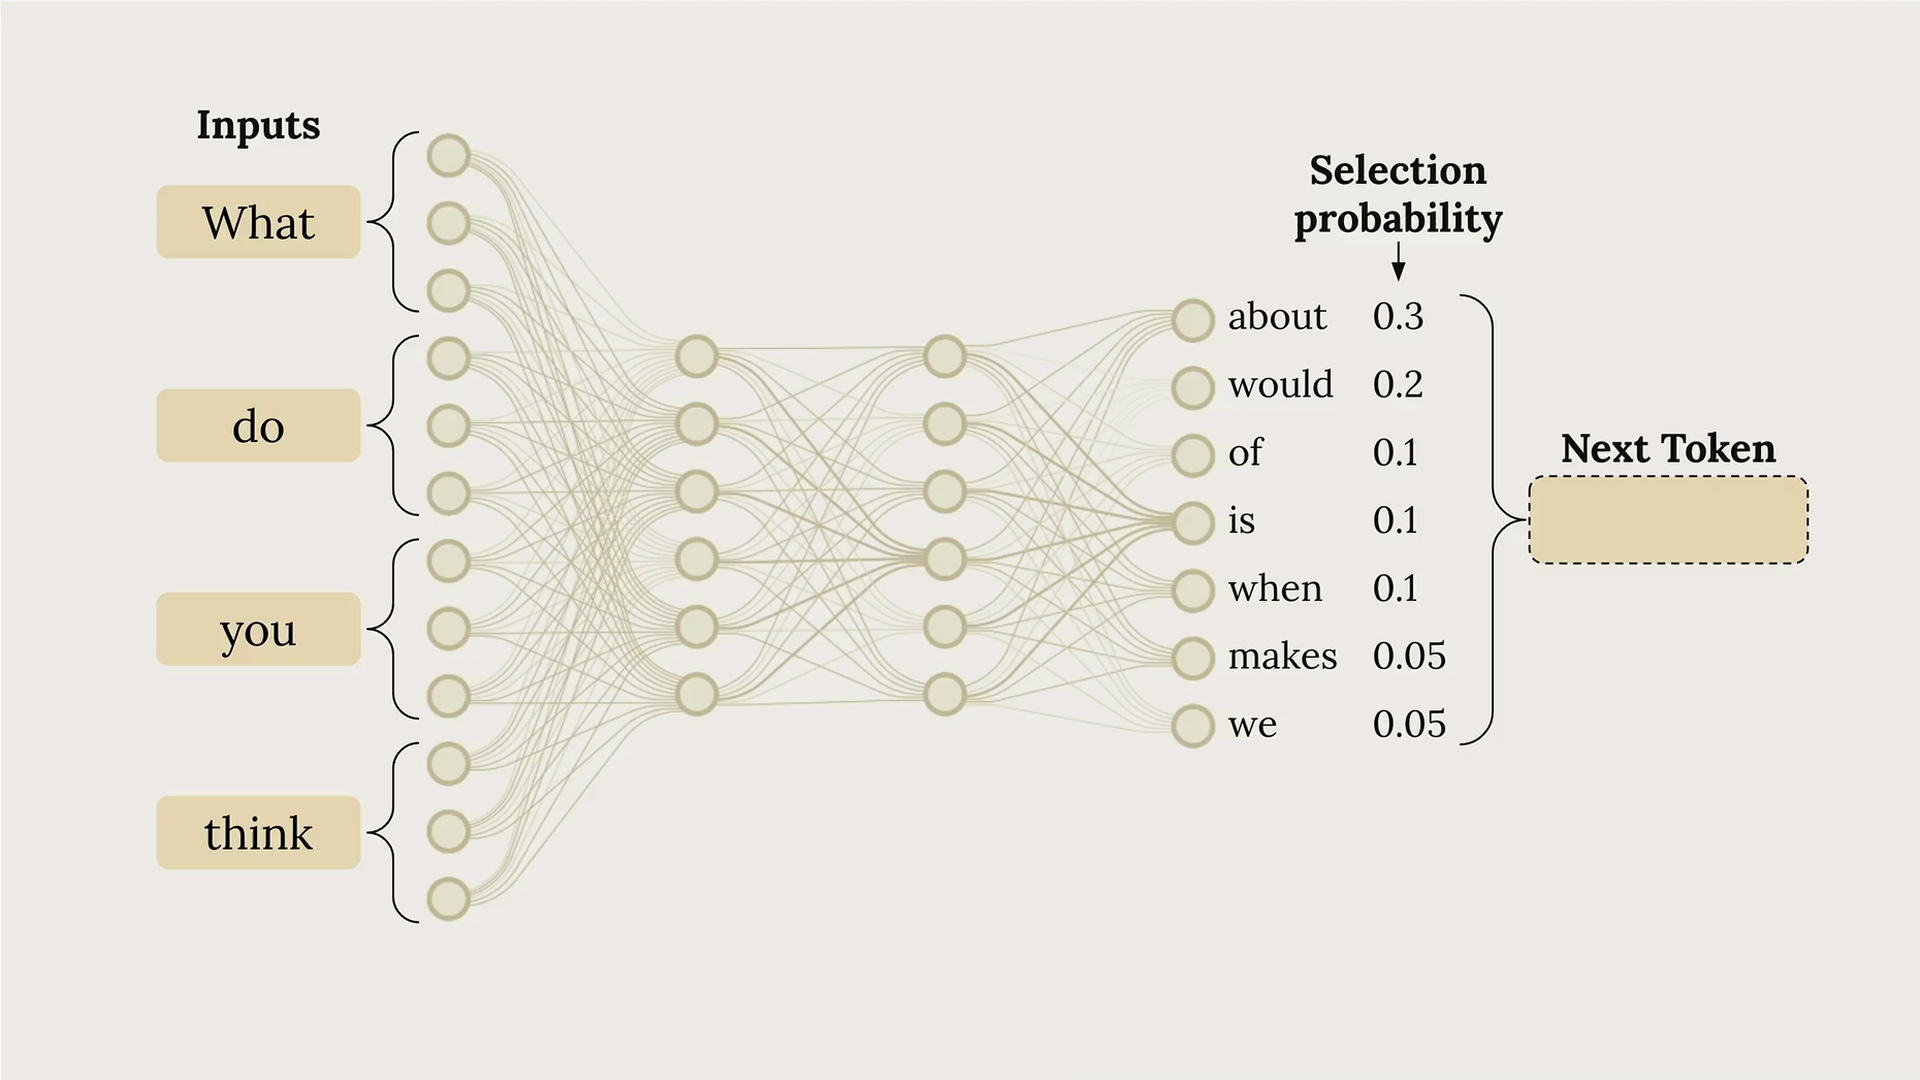

Temperature is a decimal value between 0 and 1 that directly influences these selection probabilities. It's like adjusting the "creativity dial" on Claude's responses. Higher the temperature, more creative or random Claude is and lower the temperature, more deterministic it becomes i.e, it assigns almost 100% probability to highest probable word as temp nears zero.

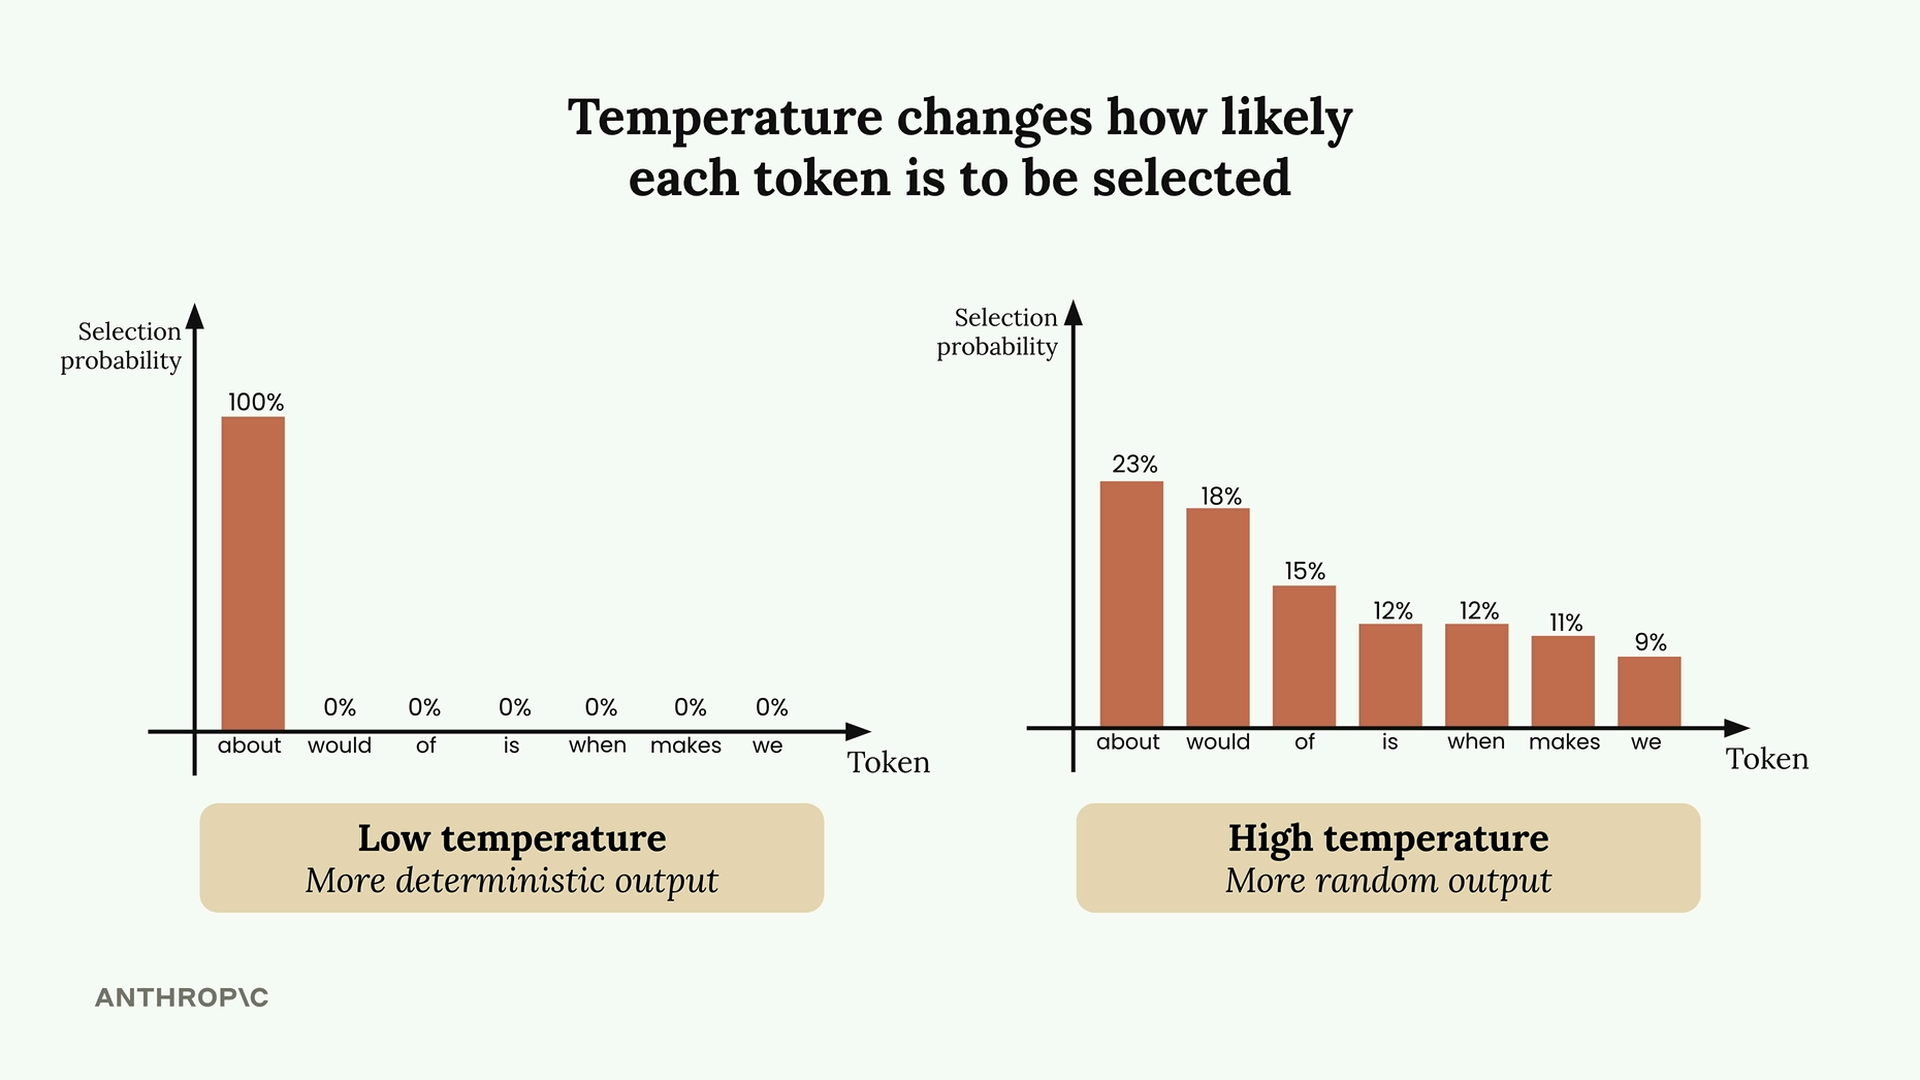

## Selecting the Right Temperature

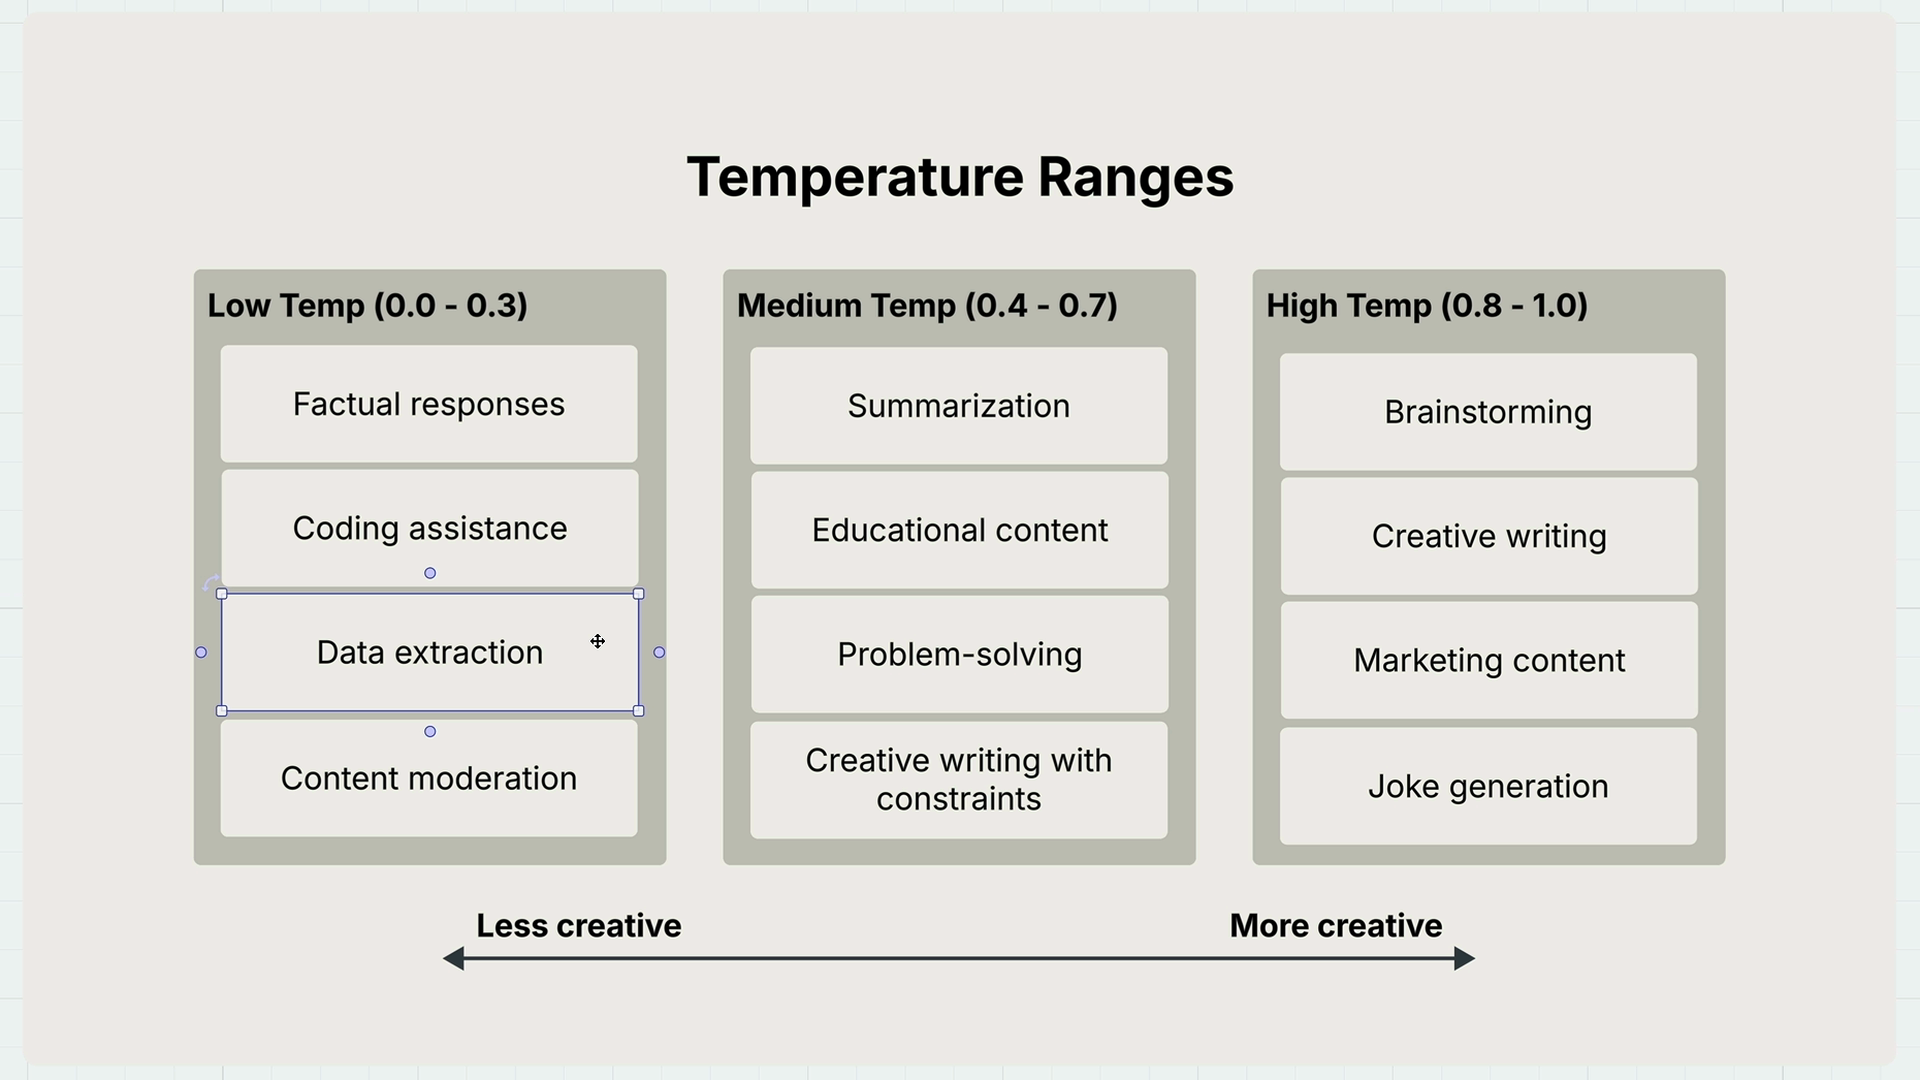

### Helper Functions

In [4]:
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)

def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)

## Modifying the chat method to pass temeprature

In [5]:
def chat(messages, system=None, temperature=1.0):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature
    }
    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message.content[0].text

## Testing Temperature Effects

In [10]:
messages = []
add_user_message(messages, "Generate a one sentence movie idea")

In [7]:
# Low temperature - more predictable
answer = chat(messages, temperature=0.1)
print("Low temperature response:", answer)

Low temperature response: A time-traveling librarian discovers that someone is systematically erasing pivotal moments from history by stealing the original books that first recorded them.


In [11]:
# High temperature - more predictable
answer = chat(messages, temperature=0.9)
print("High temperature response:", answer)

High temperature response: A retired librarian discovers that every book returned late to her small-town library contains a handwritten note predicting a local resident's death, and she has 24 hours to prevent each tragedy from coming true.
